Applied gamma (γ) on L-channel: 0.6


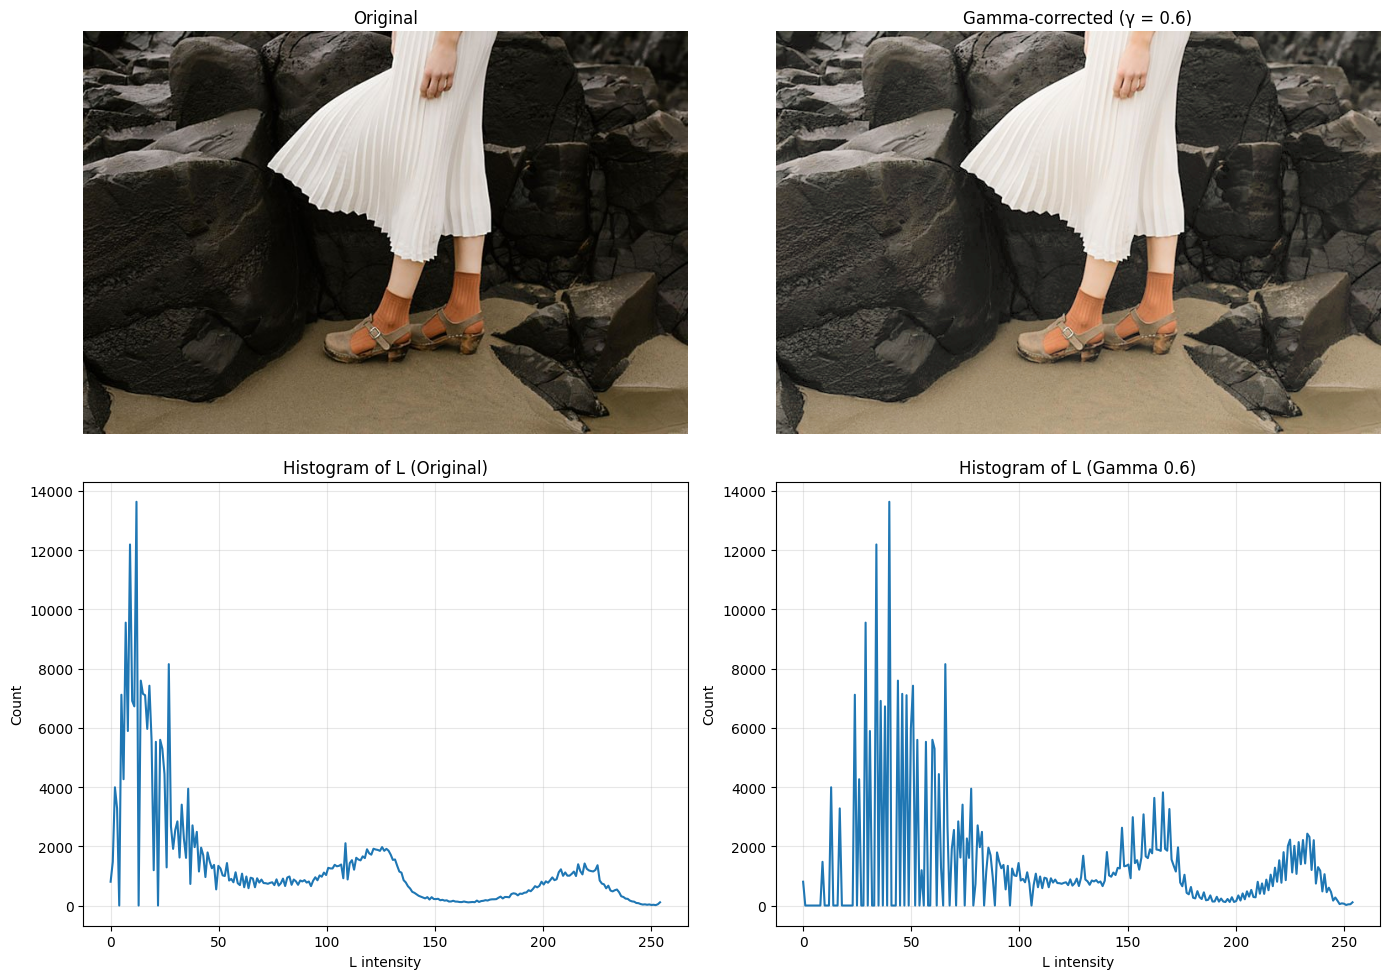

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

fname = "/content/sample_data/highlights_and_shadows.jpg"


bgr = cv2.imread(fname)
assert bgr is not None, "Image not found. Check the filename."

lab = cv2.cvtColor(bgr, cv2.COLOR_BGR2LAB)
L = lab[..., 0].astype(np.float32)


gamma = 0.6
L_norm = L / 255.0
L_corr = np.power(L_norm, gamma) * 255.0
L_corr = np.clip(L_corr, 0, 255).astype(np.uint8)

lab_corr = lab.copy()
lab_corr[..., 0] = L_corr
bgr_corr = cv2.cvtColor(lab_corr, cv2.COLOR_LAB2BGR)

rgb      = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_corr = cv2.cvtColor(bgr_corr, cv2.COLOR_BGR2RGB)

print(f"Applied gamma (γ) on L-channel: {gamma}")


fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2,2,1)
ax1.imshow(rgb)
ax1.set_title("Original")
ax1.axis("off")


ax2 = plt.subplot(2,2,2)
ax2.imshow(rgb_corr)
ax2.set_title(f"Gamma-corrected (γ = {gamma})")
ax2.axis("off")

ax3 = plt.subplot(2,2,3)
hist_L, bins = np.histogram(L.ravel(), bins=256, range=(0,255))
ax3.plot(bins[:-1], hist_L)
ax3.set_title("Histogram of L (Original)")
ax3.set_xlabel("L intensity")
ax3.set_ylabel("Count")
ax3.grid(True, alpha=0.3)


ax4 = plt.subplot(2,2,4)
hist_Lc, binsc = np.histogram(L_corr.ravel(), bins=256, range=(0,255))
ax4.plot(binsc[:-1], hist_Lc)
ax4.set_title(f"Histogram of L (Gamma {gamma})")
ax4.set_xlabel("L intensity")
ax4.set_ylabel("Count")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
